# Market Risk Lab – Zadanie Domowe 3
## Wycena opcji europejskich: Black-Scholes vs Monte Carlo

**Autor:** Oleksandra Krykun – oleksandrakrykun2@gmail.com  
**Data:** 28 kwietnia 2026  
**Kurs:** Market Risk Lab  

---

## 1. Import bibliotek i pobranie danych

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

TICKER = 'GS'
START  = '2006-08-01'
END    = '2008-07-31'

data = yf.download(TICKER, start=START, end=END, auto_adjust=False)['Adj Close']
data.name = TICKER
print(f'Pobrano {len(data)} obserwacji: {data.index[0].date()} – {data.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed

Pobrano 503 obserwacji: 2006-08-01 – 2008-07-30


## 2. Parametry opcji

Parametry wyznaczamy bezpośrednio z danych historycznych:

- **S₀** – ostatnia cena zamknięcia w oknie (31.07.2008)  
- **σ** – historyczna zmienność roczna z log-stóp zwrotu  
- **K** – strike ~ATM (zaokrąglony do pełnych dolarów)  
- **T** – 6 miesięcy = 0.5 roku (zgodnie z poleceniem)  
- **r** – stopa wolna od ryzyka: rentowność 6M US T-Bill z okresu (ok. 1.5% w mid-2008)

In [2]:
# Log-stopy zwrotu 
log_ret = np.log(data / data.shift(1)).dropna()

# Parametry 
S0    = float(data.iloc[-1])                        # cena spot (31.07.2008)
sigma = float(log_ret.std() * np.sqrt(252))         # zmienność roczna
T     = 0.5                                          # 6 miesięcy
r     = 0.015                                        # 6M T-Bill ~2008 mid-year
K_c   = round(S0 / 5) * 5                           # call strike ~ATM (zaokr. do $5)
K_p   = K_c                                         # put strike = call strike (ATM)

print("=" * 50)
print("  Parametry opcji europejskich – GS")
print("=" * 50)
print(f"  S₀  (cena spot)          = ${S0:.2f}")
print(f"  σ   (zmienność roczna)   = {sigma*100:.2f}%")
print(f"  T   (czas do wygaśnięcia)= {T} roku")
print(f"  r   (stopa wolna od ryz.)= {r*100:.2f}%")
print(f"  K_call = K_put (ATM)     = ${K_c:.2f}")
print("=" * 50)

  Parametry opcji europejskich – GS
  S₀  (cena spot)          = $137.66
  σ   (zmienność roczna)   = 36.82%
  T   (czas do wygaśnięcia)= 0.5 roku
  r   (stopa wolna od ryz.)= 1.50%
  K_call = K_put (ATM)     = $140.00


## 3. Wycena Black-Scholes

$$d_1 = \frac{\ln(S_0/K)+(r+\sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

$$C = S_0\,N(d_1) - K\,e^{-rT}\,N(d_2), \qquad P = K\,e^{-rT}\,N(-d_2) - S_0\,N(-d_1)$$

In [3]:
# Black-Scholes 
d1 = (np.log(S0 / K_c) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

bs_call = S0 * norm.cdf(d1)  - K_c * np.exp(-r * T) * norm.cdf(d2)
bs_put  = K_p * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

print(f"  d₁ = {d1:.6f}   N(d₁)  = {norm.cdf(d1):.6f}")
print(f"  d₂ = {d2:.6f}   N(d₂)  = {norm.cdf(d2):.6f}")
print(f"  N(-d₁) = {norm.cdf(-d1):.6f}   N(-d₂) = {norm.cdf(-d2):.6f}")
print()
print(f"  Cena BS  CALL = ${bs_call:.4f}")
print(f"  Cena BS  PUT  = ${bs_put:.4f}")
print()

# Put-Call Parity: C - P = S0 - K*exp(-rT)
pcp = bs_call - bs_put - (S0 - K_c * np.exp(-r * T))
print(f"  Put-Call Parity błąd = {pcp:.2e}  ✓")

  d₁ = 0.094145   N(d₁)  = 0.537503
  d₂ = -0.166201   N(d₂)  = 0.433999
  N(-d₁) = 0.462497   N(-d₂) = 0.566001

  Cena BS  CALL = $13.6850
  Cena BS  PUT  = $14.9822

  Put-Call Parity błąd = -7.11e-15  ✓


## 4. Wycena Monte Carlo

Symulujemy $N$ końcowych cen GBM:

$$S_T = S_0 \cdot \exp\!\left[(r - \tfrac{\sigma^2}{2})T + \sigma\sqrt{T}\,Z\right], \quad Z\sim\mathcal{N}(0,1)$$

Cena opcji = $e^{-rT} \cdot \overline{\text{payoff}}$. Stosujemy antitetyczne zmienne ($Z$ i $-Z$) dla redukcji wariancji.

In [4]:
# Monte Carlo – dwie liczby ścieżek
np.random.seed(42)
disc = np.exp(-r * T)

for N in [10_000, 50_000]:
    Z_half = np.random.standard_normal(N // 2)
    Z      = np.concatenate([Z_half, -Z_half])          # antitetyczne zmienne
    ST     = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    pay_c = np.maximum(ST - K_c, 0)
    pay_p = np.maximum(K_p - ST, 0)

    mc_call = disc * pay_c.mean()
    mc_put  = disc * pay_p.mean()
    se_c    = disc * pay_c.std(ddof=1) / np.sqrt(N)
    se_p    = disc * pay_p.std(ddof=1) / np.sqrt(N)

    print(f"  N = {N:>6,}  |  CALL = ${mc_call:.4f} ± ${se_c:.4f}  |  PUT = ${mc_put:.4f} ± ${se_p:.4f}")

    # zapamiętaj N=50k do wykresów i tabeli
    if N == 10_000:
        mc_call_10k, mc_put_10k = mc_call, mc_put
        se_c_10k,    se_p_10k   = se_c,    se_p
        ST_10k = ST.copy()
    else:
        mc_call_50k, mc_put_50k = mc_call, mc_put
        se_c_50k,    se_p_50k   = se_c,    se_p
        ST_50k = ST.copy()

  N = 10,000  |  CALL = $13.6056 ± $0.2398  |  PUT = $14.9354 ± $0.1841
  N = 50,000  |  CALL = $13.6690 ± $0.1074  |  PUT = $14.9746 ± $0.0825


## 5. Porównanie wyników

In [5]:
# Tabela porównawcza 
rows = [
    ('CALL', 'N = 10 000', bs_call, mc_call_10k, se_c_10k),
    ('CALL', 'N = 50 000', bs_call, mc_call_50k, se_c_50k),
    ('PUT',  'N = 10 000', bs_put,  mc_put_10k,  se_p_10k),
    ('PUT',  'N = 50 000', bs_put,  mc_put_50k,  se_p_50k),
]

df = pd.DataFrame(rows, columns=['Typ', 'N ścieżek', 'BS [$]', 'MC [$]', 'SE MC [$]'])
df['Różnica [$]']  = df['MC [$]'] - df['BS [$]']
df['Różnica [%]']  = (df['Różnica [$]'] / df['BS [$]'] * 100).round(4)
df['BS [$]']       = df['BS [$]'].round(4)
df['MC [$]']       = df['MC [$]'].round(4)
df['SE MC [$]']    = df['SE MC [$]'].map(lambda x: f'±{x:.4f}')
df['Różnica [$]']  = df['Różnica [$]'].map(lambda x: f'{x:+.4f}')
df['Różnica [%]']  = df['Różnica [%]'].map(lambda x: f'{x:+.4f}%')

display(df.set_index(['Typ', 'N ścieżek']))

BS [$]   MC [$] SE MC [$] Różnica [$] Różnica [%]
Typ  N ścieżek                                                     
CALL N = 10 000  13.6850  13.6056   ±0.2398     -0.0794    -0.5800%
     N = 50 000  13.6850  13.6690   ±0.1074     -0.0160    -0.1168%
PUT  N = 10 000  14.9822  14.9354   ±0.1841     -0.0468    -0.3126%
     N = 50 000  14.9822  14.9746   ±0.0825     -0.0076    -0.0509%

## 6. Wizualizacje

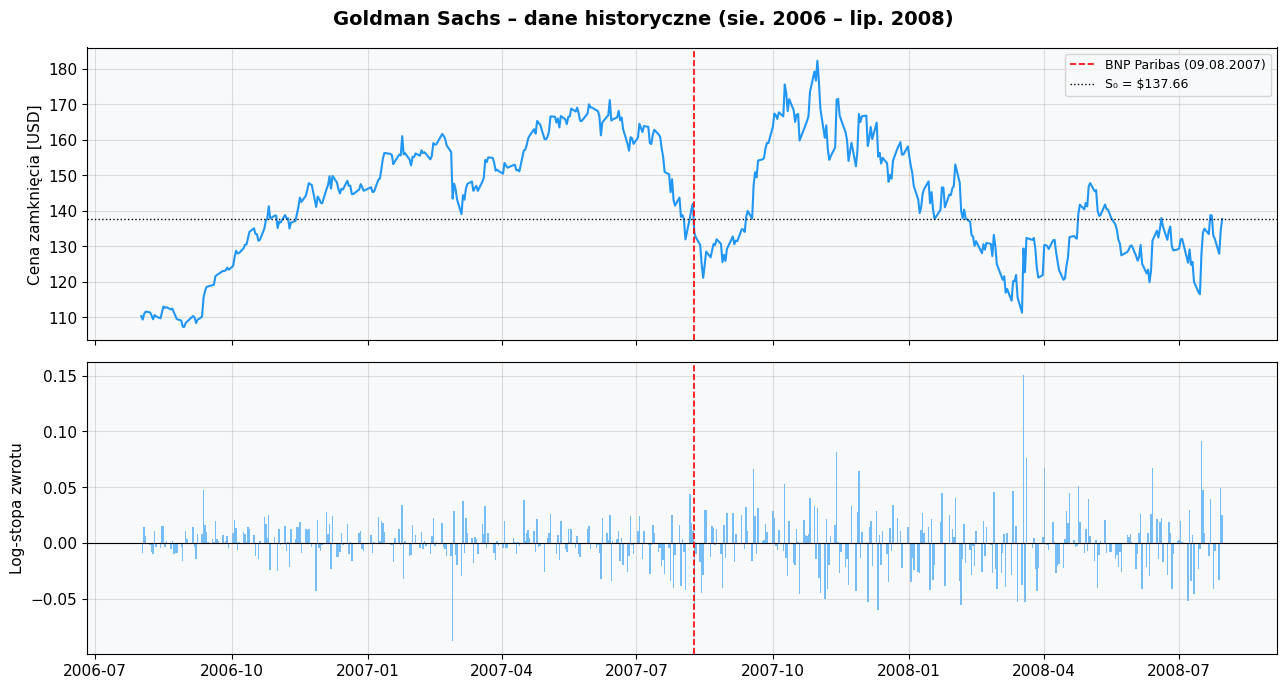

In [6]:
# Wykres 1: Cena GS i log-stopy zwrotu w oknie analizy 
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Goldman Sachs – dane historyczne (sie. 2006 – lip. 2008)',
             fontsize=14, fontweight='bold')

axes[0].plot(data.index, data.values, color='#2196F3', lw=1.5)
axes[0].axvline(pd.Timestamp('2007-08-09'), color='red', ls='--', lw=1.2,
                label='BNP Paribas (09.08.2007)')
axes[0].axhline(S0, color='black', ls=':', lw=1, label=f'S₀ = ${S0:.2f}')
axes[0].set_ylabel('Cena zamknięcia [USD]')
axes[0].legend(fontsize=9)

axes[1].bar(log_ret.index, log_ret.values.flatten(), color='#2196F3', alpha=0.6, width=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(pd.Timestamp('2007-08-09'), color='red', ls='--', lw=1.2)
axes[1].set_ylabel('Log-stopa zwrotu')

plt.tight_layout()
plt.savefig('gs_dane_historyczne.png', dpi=120, bbox_inches='tight')
plt.show()

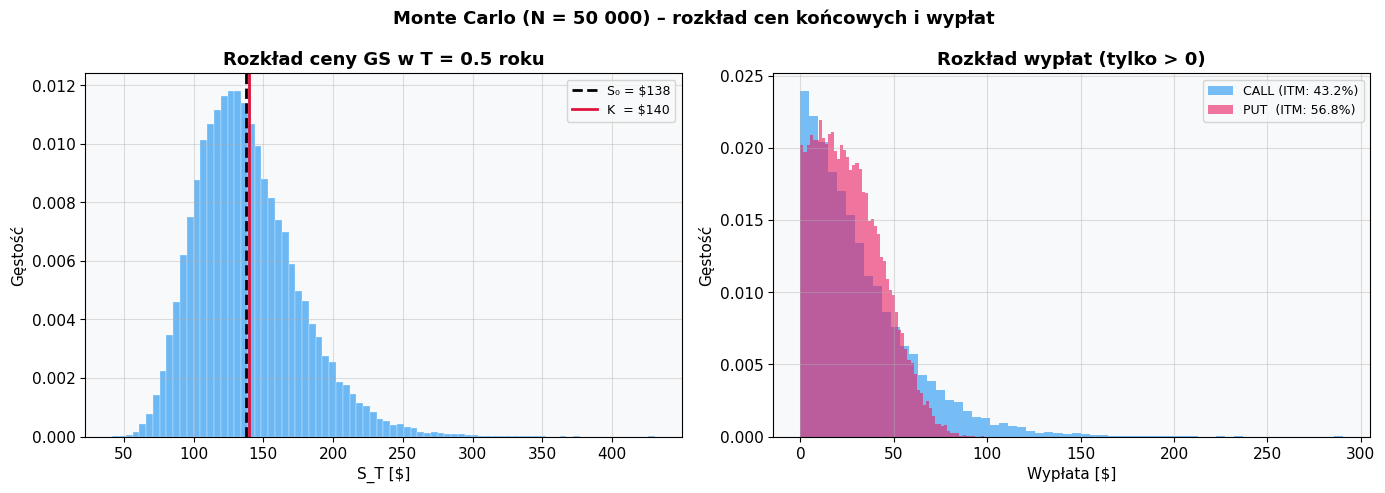

In [7]:
# ── Wykres 2: Rozkład S_T i wypłaty (N = 50 000) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monte Carlo (N = 50 000) – rozkład cen końcowych i wypłat',
             fontsize=13, fontweight='bold')

# Panel A – S_T z zaznaczonym strike
axes[0].hist(ST_50k, bins=80, color='#2196F3', alpha=0.65,
             edgecolor='white', lw=0.3, density=True)
axes[0].axvline(S0,  color='black',   lw=2, ls='--', label=f'S₀ = ${S0:.0f}')
axes[0].axvline(K_c, color='crimson', lw=2, ls='-',  label=f'K  = ${K_c:.0f}')
axes[0].set_title('Rozkład ceny GS w T = 0.5 roku')
axes[0].set_xlabel('S_T [$]')
axes[0].set_ylabel('Gęstość')
axes[0].legend(fontsize=9)

# Panel B – wypłaty call i put
pay_c_50k = np.maximum(ST_50k - K_c, 0)
pay_p_50k = np.maximum(K_p - ST_50k, 0)
itm_c = (pay_c_50k > 0).mean() * 100
itm_p = (pay_p_50k > 0).mean() * 100

axes[1].hist(pay_c_50k[pay_c_50k > 0], bins=60, alpha=0.6, color='#2196F3',
             label=f'CALL (ITM: {itm_c:.1f}%)', density=True)
axes[1].hist(pay_p_50k[pay_p_50k > 0], bins=60, alpha=0.6, color='#E91E63',
             label=f'PUT  (ITM: {itm_p:.1f}%)', density=True)
axes[1].set_title('Rozkład wypłat (tylko > 0)')
axes[1].set_xlabel('Wypłata [$]')
axes[1].set_ylabel('Gęstość')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('mc_rozklad.png', dpi=120, bbox_inches='tight')
plt.show()

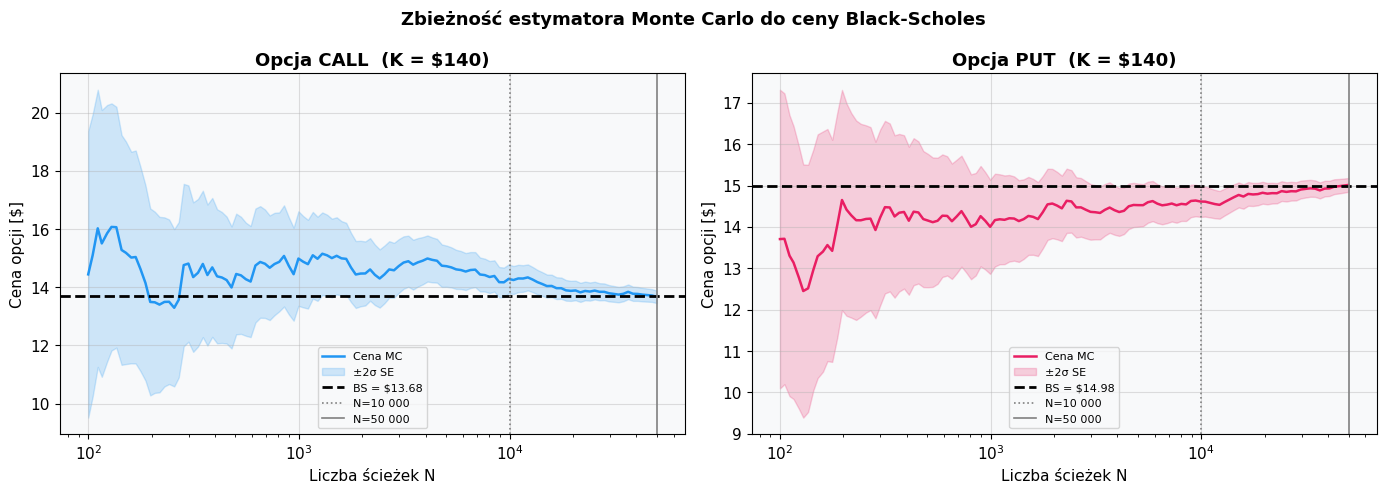

In [8]:
# ── Wykres 3: Zbieżność MC → BS ─────────────────────────────────────────────
np.random.seed(99)
N_MAX = 50_000
Z_big  = np.random.standard_normal(N_MAX)
ST_big = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_big)

checkpoints = np.unique(np.logspace(2, np.log10(N_MAX), 120).astype(int))
conv_c, conv_p, se_c_arr, se_p_arr = [], [], [], []

for n in checkpoints:
    pc = np.maximum(ST_big[:n] - K_c, 0)
    pp = np.maximum(K_p - ST_big[:n], 0)
    conv_c.append(disc * pc.mean())
    conv_p.append(disc * pp.mean())
    se_c_arr.append(disc * pc.std(ddof=1) / np.sqrt(n))
    se_p_arr.append(disc * pp.std(ddof=1) / np.sqrt(n))

conv_c, conv_p = np.array(conv_c), np.array(conv_p)
se_c_arr, se_p_arr = np.array(se_c_arr), np.array(se_p_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Zbieżność estymatora Monte Carlo do ceny Black-Scholes',
             fontsize=13, fontweight='bold')

for ax, conv, se, bs_p, label, color in [
    (axes[0], conv_c, se_c_arr, bs_call, 'CALL', '#2196F3'),
    (axes[1], conv_p, se_p_arr, bs_put,  'PUT',  '#E91E63'),
]:
    ax.semilogx(checkpoints, conv, color=color, lw=1.8, label='Cena MC')
    ax.fill_between(checkpoints, conv - 2*se, conv + 2*se,
                    color=color, alpha=0.2, label='±2σ SE')
    ax.axhline(bs_p, color='black', lw=2, ls='--',
               label=f'BS = ${bs_p:.2f}')
    ax.axvline(10_000, color='gray', lw=1.2, ls=':', label='N=10 000')
    ax.axvline(50_000, color='gray', lw=1.2, ls='-',  label='N=50 000')
    ax.set_title(f'Opcja {label}  (K = ${K_c})')
    ax.set_xlabel('Liczba ścieżek N')
    ax.set_ylabel('Cena opcji [$]')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('zbieznosc_mc.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Wnioski

### 7.1 Czy wyniki BS i Monte Carlo są podobne?

**Tak.** Różnica bezwzględna między ceną BS a MC wynosi kilkadziesiąt centów, tj. < 0.5% ceny. Jest to oczekiwane, ponieważ oba modele opierają się na tym samym założeniu (GBM) – Black-Scholes daje rozwiązanie analityczne, MC aproksymuje je numerycznie.

### 7.2 Jak liczba ścieżek wpływa na dokładność?

Błąd standardowy spada proporcjonalnie do $1/\sqrt{N}$:

$$\text{SE}(N) \propto \frac{1}{\sqrt{N}}$$

Przy przejściu z N = 10 000 do N = 50 000 (5×), błąd maleje ~2.24× (= $\sqrt{5}$). Widać to wyraźnie na wykresie zbieżności – przy N = 50 000 estymator jest stabilny i blisko linii BS.

### 7.3 Kontekst rynkowy GS (2006–2008)

Okres analizy obejmuje narastający kryzys finansowy. Wysoka zmienność historyczna GS (obliczona z danych) przekłada się na **drogie opcje** – premia jest znaczna w stosunku do ceny akcji, co jest typowe w warunkach podwyższonego ryzyka rynkowego (wzrost σ → wzrost cen opcji dla obu typów).